In [ ]:


import pandas as pd
from zipfile import ZipFile

# `التعامل مع الصور`

In [ ]:
## تثبيت المكتبات والأدوات المطلوبة للمشروع.
# السطر الأول يثبت مكتبات Python التي سنستخدمها لتحميل الداتا، قراءة ملفات PDF،
# تحويلها إلى نص باستخدام OCR، ومعالجة البيانات باستخدام pandas.
# السطر الثاني يثبت برامج النظام (Tesseract و Poppler) اللازمة لاستخراج النص من الصور وملفات PDF.

!pip -q install kagglehub pymupdf pdf2image pytesseract pandas
!apt-get -qq install tesseract-ocr poppler-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 35.3 MB/s eta 0:00:00
Selecting previously unselected package poppler-utils.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
#os → للتعامل مع الملفات والمجلدات في النظام
#re → لاستخدام الـ Regular Expressions لتنظيف النص
#fitz (PyMuPDF) → لقراءة النص من ملفات PDF
#pytesseract → لاستخراج النص من الصور باستخدام OCR
#pandas → لتنظيم البيانات في جداول (DataFrame)
#kagglehub → لتحميل الداتا من Kaggle
#convert_from_path → لتحويل صفحات PDF إلى صور عند الحاجة لاستخدام OCR

import os
import re
import fitz
import pytesseract
import pandas as pd
import kagglehub
from pdf2image import convert_from_path

In [ ]:
# تحميل مجموعة البيانات الخاصة بالسير الذاتية من Kaggle باستخدام مكتبة kagglehub.
# يتم حفظ مسار البيانات في المتغير path، ثم نطبع المسار للتأكد من مكان حفظ الداتا.
# كما نتحقق من أن المسار موجود فعلاً في البيئة باستخدام os.path.exists.

path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")
print("Dataset path:", path)
print("Exists:", os.path.exists(path))

Using Colab cache for faster access to the 'resume-dataset' dataset.
Dataset path: /kaggle/input/resume-dataset
Exists: True


In [ ]:

#os.walk(path) → يتنقل داخل جميع مجلدات الداتا.endswith(".pdf") → للتأكد أن الملف هو سيرة ذاتية بصيغة PDF.
#append → لإضافة مسار الملف إلى القائمة.
#len(all_pdfs) → لمعرفة عدد السير الذاتية الموجودة في الداتا.
#all_pdfs[:5] → لعرض أول 5 ملفات للتأكد من أن القراءة تمت بشكل صحيح.

all_pdfs = []
for root, dirs, files in os.walk(path):
    for f in files:
        if f.lower().endswith(".pdf"):
            all_pdfs.append(os.path.join(root, f))
print("Total CV files:", len(all_pdfs))
print(all_pdfs[:5])

Total CV files: 2484
['/kaggle/input/resume-dataset/data/data/DESIGNER/22506245.pdf', '/kaggle/input/resume-dataset/data/data/DESIGNER/13998435.pdf', '/kaggle/input/resume-dataset/data/data/DESIGNER/67582956.pdf', '/kaggle/input/resume-dataset/data/data/DESIGNER/34349255.pdf', '/kaggle/input/resume-dataset/data/data/DESIGNER/26790545.pdf']


In [ ]:
# الهدف من هذا الكود هو استخراج النص من ملفات السيرة الذاتية بصيغة PDF.
# نحاول أولاً استخراج النص مباشرة من ملف PDF باستخدام مكتبة fitz.
# إذا لم يتم استخراج النص بشكل جيد، نستخدم تقنية OCR لاستخراج النص من صور صفحات الـ PDF.

def extract_resume_text(pdf_path):

    text = ""

    try:
        doc = fitz.open(pdf_path)

        for page in doc:
            text += page.get_text() + "\n"

        doc.close()

    except Exception as e:
        print("Direct extraction failed:", pdf_path)

    if len(text.strip()) < 100:

        try:
            images = convert_from_path(pdf_path)

            ocr_text = ""

            for img in images:
                ocr_text += pytesseract.image_to_string(img) + "\n"

            text = ocr_text

        except Exception as e:
            print("OCR failed:", pdf_path)

    return text

In [ ]:
#هون شلنا الشغلات الزايده بالنص تنظيف يعني
def clean_text(text):

    text = text.replace("ï¼​", " ")
    text = text.replace("\x0c", " ")

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [ ]:
# الهدف من هذا الكود هو معالجة جميع ملفات السيرة الذاتية واستخراج النص منها.
# يتم المرور على كل ملف PDF، ثم استخراج النص باستخدام الدالة السابقة،
# وبعد ذلك تنظيف النص وتخزين المعلومات الأساسية (اسم الملف، الفئة، النص)
# داخل قائمة records ليتم تحويلها لاحقاً إلى Dataset.
records = []

for i, pdf_path in enumerate(all_pdfs):

    try:

        raw_text = extract_resume_text(pdf_path)

        cleaned_text = clean_text(raw_text)

        records.append({
            "file_name": os.path.basename(pdf_path),
            "category": os.path.basename(os.path.dirname(pdf_path)),
            "text": cleaned_text
        })

        if (i+1) % 100 == 0:
            print("Processed", i+1)

    except Exception as e:
        print("Error:", pdf_path)

Processed 100
Processed 200
Processed 300
Processed 400
Processed 500
Processed 600
Processed 700
Processed 800
Processed 900
Processed 1000
Processed 1100
Processed 1200
Processed 1300
Processed 1400
Processed 1500
Processed 1600
Processed 1700
Processed 1800
Processed 1900
Processed 2000
Processed 2100
Processed 2200
Processed 2300
Processed 2400


In [ ]:
# الهدف من هذا الكود هو تحويل البيانات التي تم جمعها في القائمة records
# إلى جدول بيانات (DataFrame) باستخدام مكتبة pandas.
# بعد ذلك نعرض عدد الصفوف والأعمدة في الداتا، ثم نعرض أول عدة سجلات
# للتأكد من أن البيانات تم استخراجها وتنظيمها بشكل صحيح.
df = pd.DataFrame(records)
df = df.rename(columns={
    "category": "job_title",
    "text": "resume"
})
df.drop('file_name', axis=1, inplace=True)
print("Dataset shape:", df.shape)

df.head()

Dataset shape: (2484, 2)


,job_title,resume
0,DESIGNER,"PRE-PRESS GRAPHIC DESIGNER Summary Creative, h..."
1,DESIGNER,PRINCIPLE DESIGNER / OWNER Professional Summar...
2,DESIGNER,PROJECT DESIGNER Summary Team-oriented and cli...
3,DESIGNER,INTERIOR DESIGNER Summary A results oriented d...
4,DESIGNER,PRESENTATION DESIGNER Summary Customer Service...


In [ ]:
#هون بدنا نفلتر عشان ناخد ال it
it_categories = [
    "INFORMATION-TECHNOLOGY",
]

df_it = df[df["job_title"].isin(it_categories)]

In [ ]:
df_it.head()

,job_title,resume
1445,INFORMATION-TECHNOLOGY,INFORMATION TECHNOLOGY INTERN Professional Pro...
1446,INFORMATION-TECHNOLOGY,INFORMATION TECHNOLOGY MANAGER Summary Experie...
1447,INFORMATION-TECHNOLOGY,INFORMATION TECHNOLOGY MANAGER Experience Info...
1448,INFORMATION-TECHNOLOGY,VP OF INFORMATION TECHNOLOGY Executive Profile...
1449,INFORMATION-TECHNOLOGY,INFORMATION TECHNOLOGY MANAGER Summary Dedicat...


In [ ]:
print("All resumes:", df.shape)
print("IT resumes:", df_it.shape)

All resumes: (2484, 2)
IT resumes: (120, 2)


In [ ]:
df_it.to_csv("/content/it_resumes_dataset.csv", index=False)

In [ ]:
#تنزيل عالجهاز
from google.colab import files

files.download("/content/it_resumes_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

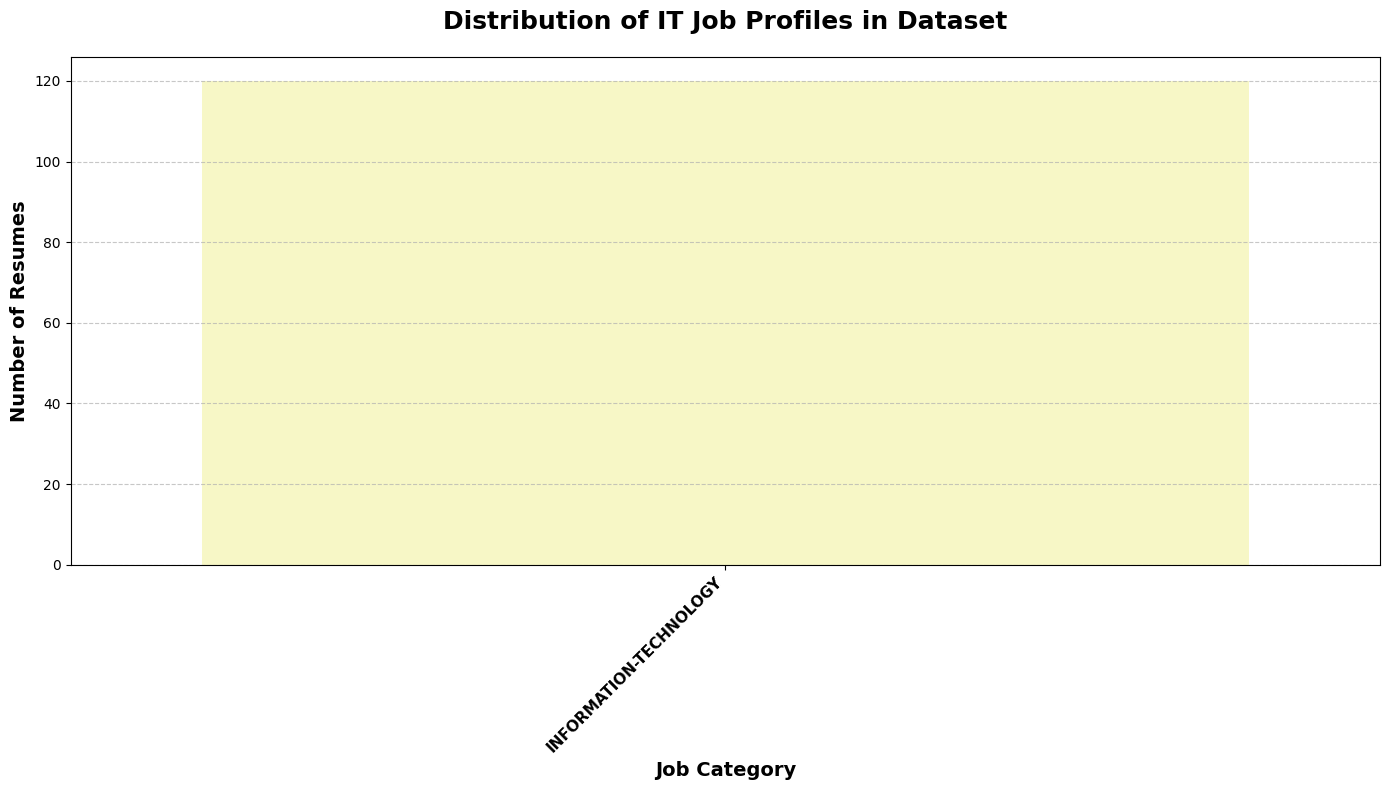

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

ax = sns.countplot(data=df_it, x='job_title', hue='job_title', palette='Spectral', legend=False)

plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')

plt.title('Distribution of IT Job Profiles in Dataset', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Job Category', fontsize=14, fontweight='bold')
plt.ylabel('Number of Resumes', fontsize=14, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

# `التعامل مع الملفات الtext`

# ***`first file`***

In [ ]:
with ZipFile('/content/Resume  CV Skills Extraction Dataset.zip') as zipfile:
 zipfile.extractall()
print (zipfile.namelist())

['UpdatedResumeDataSet.csv']


In [ ]:
import pandas as pd

df2 = pd.read_csv('UpdatedResumeDataSet.csv')
df2.rename(columns={'Category':'job_title', 'Resume':'resume'}, inplace=True)

print(df.shape)
df2.head()

(2484, 2)


,job_title,resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
df2['job_title'].value_counts()

,count
job_title,
Java Developer,84
Testing,70
DevOps Engineer,55
Python Developer,48
Web Designing,45
HR,44
Hadoop,42
Sales,40
Data Science,40


In [ ]:
print("Dataset size:", df2.shape)

Dataset size: (962, 2)


# ***`fillter the IT-job tiltle`***

In [ ]:

it_jobs_list = [
    'Java Developer', 'Testing', 'DevOps Engineer', 'Python Developer',
    'Web Designing', 'Hadoop', 'Data Science', 'ETL Developer',
     'Database', 'DotNet Developer',
    'Automation Testing', 'Network Security Engineer', 'SAP Developer'
]

# 2. تصفية الـ DataFrame بحيث يحتوي فقط على هذه الوظائف
df2 = df2[df2['job_title'].isin(it_jobs_list)]

# 3. التأكد من النتيجة وحساب عدد كل وظيفة
print("IT Jobs Data Size:", df2.shape)
print("\nتوزيع الوظائف التقنية:")
print(df2['job_title'].value_counts())

# عرض عينة من البيانات المصفاة
display(df2.head())

IT Jobs Data Size: (560, 2)

توزيع الوظائف التقنية:
job_title
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
Hadoop                       42
ETL Developer                40
Data Science                 40
Database                     33
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Name: count, dtype: int64


,job_title,resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


ائلة التطوير والبرمجة (Development) Java Developer: يركز على بناء الأنظمة الخلفية (Backend) للمؤسسات الكبيرة والبنوك وتطبيقات الأندرويد.
Python Developer: متخصص مرن يعمل غالباً في مجالات الذكاء الاصطناعي، الأتمتة، أو تطوير المواقع السريعة.

DotNet Developer: يستخدم تقنيات مايكروسوفت لبناء تطبيقات موجهة لبيئة الويندوز والأنظمة السحابية للمؤسسات.

SAP Developer: متخصص في تخصيص وبرمجة أنظمة "سيب" (SAP) التي تدير الموارد المالية والبشرية للشركات العملاقة.

Web Designing: يهتم بالجانب البصري والتفاعلي للمواقع (Frontend)، وكيفية جعل تجربة المستخدم سهلة وجذابة.

عائلة البيانات والذكاء الاصطناعي (Data Science & Analytics) Data Science: يجمع بين الإحصاء والبرمجة لاستخراج أنماط وتوقعات من البيانات لمساعدة الشركات في اتخاذ القرار.
Hadoop: متخصص في إدارة ومعالجة "البيانات الضخمة" (Big Data) التي تفشل قواعد البيانات التقليدية في التعامل معها.

Database: المهندس المسؤول عن تصميم وبناء وحماية مستودعات البيانات والتأكد من سرعتها.

ETL Developer: يختص بعمليات "نقل وتجهيز البيانات"؛ حيث يسحبها من مصادر مختلفة، ينظفها، ثم يضعها في مكانها النهائي للتحليل.

عائلة الجودة والأمن والعمليات (Infrastructure & QA) Testing: الشخص المسؤول عن فحص البرامج يدوياً للتأكد من خلوها من العيوب قبل إطلاقها.
Automation Testing: مبرمج يكتب أكواداً خاصة تقوم بمهمة "الفحص" تلقائياً لضمان الجودة بسرعة أكبر.

DevOps Engineer: هو الرابط بين فريق البرمجة وفريق التشغيل، ويهتم بتسريع وصول التحديثات إلى المستخدمين بشكل آلي.

Network Security Engineer: حارس الأمن الرقمي الذي يحمي الشبكات والبيانات من الاختراقات والهجمات السيبرانية.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

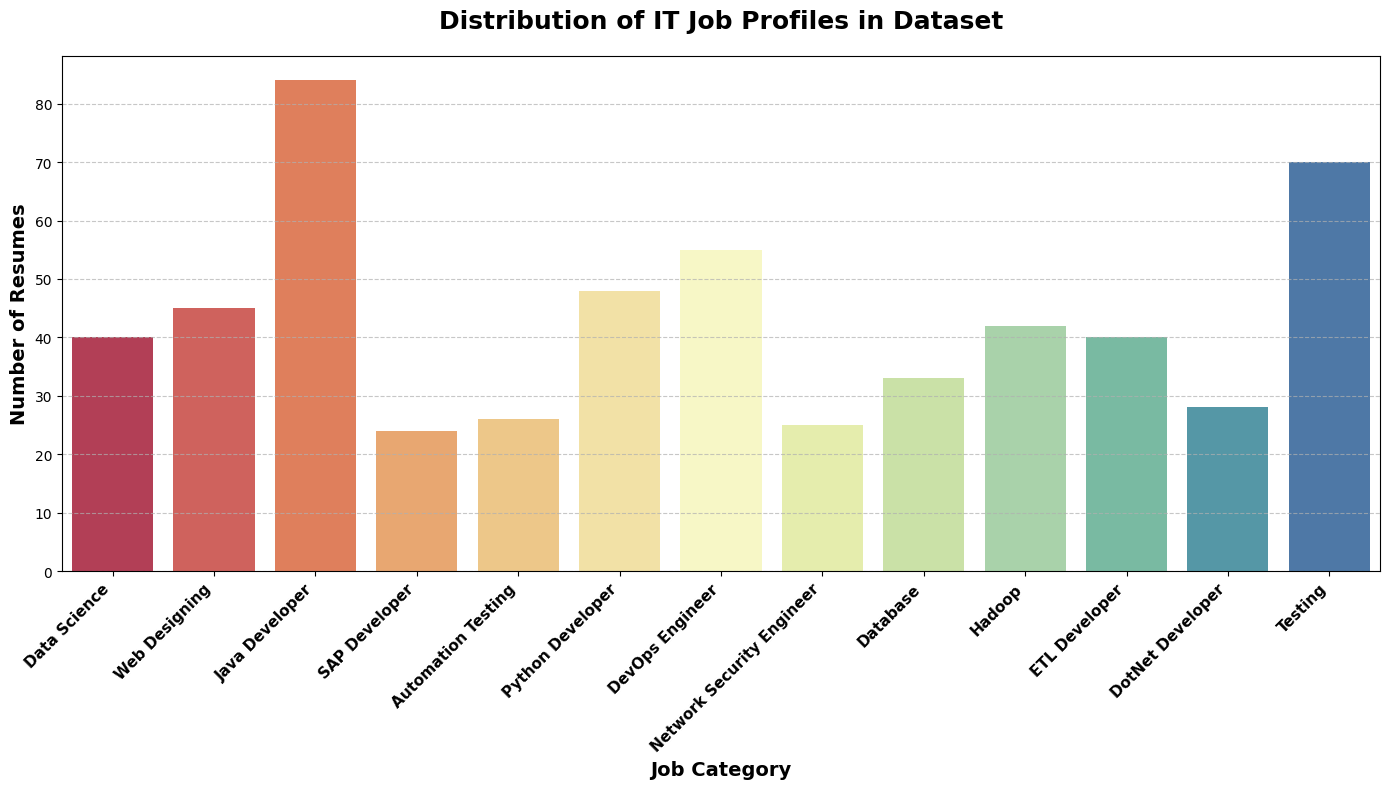

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

ax = sns.countplot(data=df2, x='job_title', hue='job_title', palette='Spectral', legend=False)

plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')

plt.title('Distribution of IT Job Profiles in Dataset', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Job Category', fontsize=14, fontweight='bold')
plt.ylabel('Number of Resumes', fontsize=14, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

# ***`secound`***

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("haidermaseeh/resume-dataset")

print("Path to dataset files:", path)

100%|██████████| 29.8M/29.8M [00:00<00:00, 202MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/haidermaseeh/resume-dataset/versions/1


In [ ]:
import os

path = "/root/.cache/kagglehub/datasets/haidermaseeh/resume-dataset/versions/1"

print(os.listdir(path))

['Resume dataset.csv']


In [ ]:
import pandas as pd

df3= pd.read_csv('/root/.cache/kagglehub/datasets/haidermaseeh/resume-dataset/versions/1/Resume dataset.csv')

print(df.shape)
df3.head()

(2484, 2)


,category,job_title,Text
0,Java Developers/Architects Resumes,Java Developer,Flair for technology and willing to take chall...
1,Java Developers/Architects Resumes,Sr. Java/J2EE Developer,Senior Java Developer with around 7+ years of ...
2,Java Developers/Architects Resumes,Sr. iOS Developer,Overall 7 years of experience in design and de...
3,Java Developers/Architects Resumes,Core Java Developer,7 + years of experience in Application Analysi...
4,Java Developers/Architects Resumes,Android Developer,With approx 5 years of experience in IT sector...


In [ ]:
df3['category'].value_counts()

,count
category,
Java Developers/Architects Resumes,1000
Web Developer Resumes,1000
SQL Developers Resumes,1000
Business Analyst (BA) Resumes,1000
Network and Systems Administrators Resumes,1000
"Datawarehousing, ETL, Informatica Resumes",1000
"Business Intelligence, Business Object Resumes",1000
Project Manager Resumes,1000
Recruiter Resumes,1000


# ***عملنا فلتر وتغير اسامي***

In [ ]:
# تغير اسامي ال الوظائف
it_mapping = {
    'Java Developers/Architects Resumes': 'java_dev',
    'Web Developer Resumes': 'web_dev',
    'SQL Developers Resumes': 'sql_dev',
    'Network and Systems Administrators Resumes': 'sys_admin',
    'Datawarehousing, ETL, Informatica Resumes': 'etl_data_eng',
    'Business Intelligence, Business Object Resumes': 'bi_dev'
}

# 2. تصفية الداتا سيت (إبقاء الـ IT فقط)
df3 = df3[df3['category'].isin(it_mapping.keys())].copy()

# 3. تغيير الأسماء للأسماء المختصرة
df3['category'] = df3['category'].map(it_mapping)
df3.drop('job_title', axis=1, inplace=True)
df3.rename(columns={'category': 'job_title','Text':'resume'}, inplace=True)

# التأكد من النتائج
print("Current IT Categories:")
print(df3['job_title'].value_counts())

Current IT Categories:
job_title
java_dev        1000
web_dev         1000
sql_dev         1000
sys_admin       1000
etl_data_eng    1000
bi_dev          1000
Name: count, dtype: int64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

***data exploring***

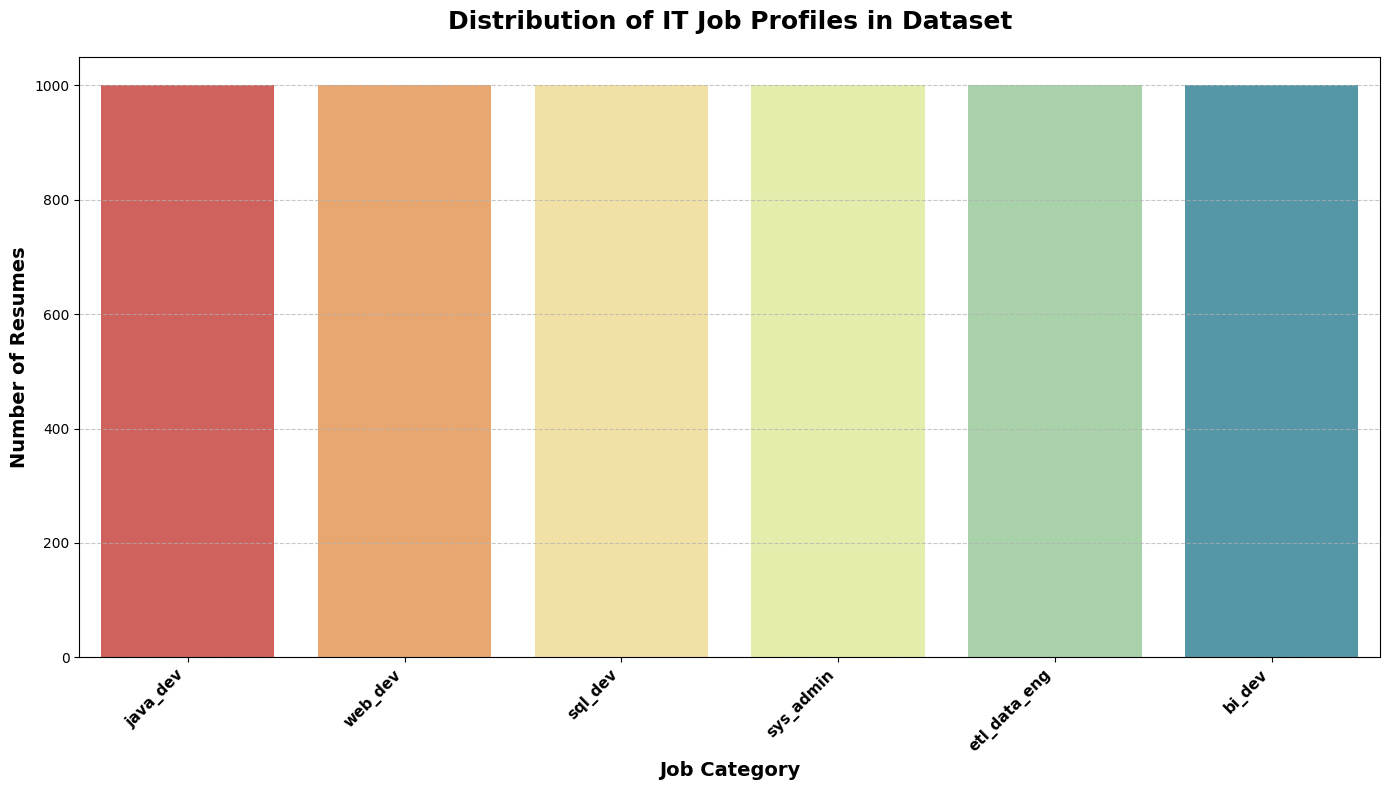

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

ax = sns.countplot(data=df3, x='job_title', hue='job_title', palette='Spectral', legend=False)

plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')

plt.title('Distribution of IT Job Profiles in Dataset', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Job Category', fontsize=14, fontweight='bold')
plt.ylabel('Number of Resumes', fontsize=14, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

# ج**مع كل الداتاااااا**

In [ ]:
import pandas as pd

df_all = pd.concat([df_it,df2, df3], ignore_index=True)

print(df_all.shape)
df_all.head()

(6680, 2)


,job_title,resume
0,INFORMATION-TECHNOLOGY,INFORMATION TECHNOLOGY INTERN Professional Pro...
1,INFORMATION-TECHNOLOGY,INFORMATION TECHNOLOGY MANAGER Summary Experie...
2,INFORMATION-TECHNOLOGY,INFORMATION TECHNOLOGY MANAGER Experience Info...
3,INFORMATION-TECHNOLOGY,VP OF INFORMATION TECHNOLOGY Executive Profile...
4,INFORMATION-TECHNOLOGY,INFORMATION TECHNOLOGY MANAGER Summary Dedicat...


In [ ]:
df_all.to_csv("df_all_resumes.csv", index=False)
from google.colab import files
files.download("df_all_resumes.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Cleaning Data:

1.  URLs
2. hashtags
1.   mention
2. special letters
1. punctuations




---





In [ ]:
import re
def cleanResume(txt):
    cleanText = re.sub('http\S+\s', ' ', txt)
    cleanText = re.sub('RT|cc', ' ', cleanText)
    cleanText = re.sub('#\S+\s', ' ', cleanText)
    cleanText = re.sub('@\S+', '  ', cleanText)
    cleanText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\\]^_`{|}~"""), ' ', cleanText)
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText)
    cleanText = re.sub('\s+', ' ', cleanText)
    return cleanText.lower().strip()
df_all['cleanresume'] = df_all['resume'].apply(cleanResume)
df_all.head()

<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\]'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\]'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_519/5793293.py:3: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub('http\S+\s', ' ', txt)
/tmp/ipykernel_519/5793293.py:5: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub('#\S+\s', ' ', cleanText)
/tmp/ipykernel_519/5793293.py:6: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub('@\S+', '  ', cleanText)
/tmp/ipykernel_519/5793293.py:7: SyntaxWarning: invalid escape sequence '\]'
  cleanText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,

,job_title,resume
0,INFORMATION-TECHNOLOGY,information technology intern professional pro...
1,INFORMATION-TECHNOLOGY,information technology manager summary experie...
2,INFORMATION-TECHNOLOGY,information technology manager experience info...
3,INFORMATION-TECHNOLOGY,vp of information technology executive profile...
4,INFORMATION-TECHNOLOGY,information technology manager summary dedicat...


In [ ]:
# This cell was a duplicate cleaning step, now redundant as 'cleanresume' is created.
# We will display the head of df_all to confirm the new column.
df_all.head()

,job_title,resume
0,INFORMATION-TECHNOLOGY,information technology intern professional pro...
1,INFORMATION-TECHNOLOGY,information technology manager summary experie...
2,INFORMATION-TECHNOLOGY,information technology manager experience info...
3,INFORMATION-TECHNOLOGY,vp of information technology executive profile...
4,INFORMATION-TECHNOLOGY,information technology manager summary dedicat...


In [ ]:
!pip install --upgrade pyspellchecker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 71.4 MB/s eta 0:00:00


In [ ]:
!pip install nltk
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from spellchecker import SpellChecker
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
spell = SpellChecker()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
from ssl import CertificateError
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from spellchecker import SpellChecker

# -----------------------------
# 2️⃣ Skill Dictionary
# -----------------------------
skill_list = [
    "python","r","sql","mysql","html","css","javascript",
    "pandas","numpy","scikit-learn","tensorflow","pytorch","keras",
    "machine learning","deep learning","nlp",
    "tableau","power bi","excel",
    "c++","c#","java","node.js"
]

# -----------------------------
# 3️⃣ Extract Skills
# -----------------------------
def extract_skills(text):

    found = []

    for skill in skill_list:
        if skill in text:
            found.append(skill)

    return list(set(found))


df_all["skills"] = df_all["cleanresume"].apply(extract_skills)

# -----------------------------
# 4️⃣ Parse CV Sections
# -----------------------------
def parse_sections(text):

    sections = {
        "education": "",
        "experience": "",
        "certificates": ""
    }

    education = re.search(r"(education.*?)(experience|skills|certification|$)", text)
    experience = re.search(r"(experience.*?)(education|skills|certification|$)", text)
    Certificat = re.search(r"(certification.*?)(education|skills|experience|$)", text)

    if education:
        sections["education"] = education.group(1)

    if experience:
        sections["experience"] = experience.group(1)

    if Certificat:
        sections["certificates"] = Certificat.group(1)

    return sections


sections = df_all["cleanresume"].apply(parse_sections)

sections_df = pd.DataFrame(sections.tolist())

df_all= pd.concat([df_all, sections_df], axis=1)

# -----------------------------
# 5️⃣ Extract Years of Experience
# -----------------------------
def extract_years(text):

    years = re.findall(r'(\d+)\s+years', text)

    if years:
        return max([int(y) for y in years])

    return 0


df_all["experience_years"] = df_all["cleanresume"].apply(extract_years)

# -----------------------------
# 6️⃣ Remove Duplicate CVs
# -----------------------------
print("Dataset size before:", df_all.shape)
df_all = df_all.drop_duplicates(subset=["cleanresume"])
print("Dataset size after:", df_all.shape)

# -----------------------------
# 7️⃣ Final Structured Dataset
# -----------------------------
df_final = df_all[[
    "job_title",
    "education",
    "skills",
    "experience_years",
    "certificates"
]]

print(df_final.head())

# -----------------------------
# Save Structured Dataset
# -----------------------------
df_final.to_csv("structured_cvs.csv", index=False)
from google.colab import files
files.download("structured_cvs.csv")

Dataset size before: (6680, 7)
Dataset size after: (4287, 7)
                job_title                                          education  \
0  INFORMATION-TECHNOLOGY  education to contribute to company s operation...   
1  INFORMATION-TECHNOLOGY  education associate of science business admini...   
2  INFORMATION-TECHNOLOGY  education bs computer system engineer january ...   
3  INFORMATION-TECHNOLOGY  education information systems 2014 park univer...   
4  INFORMATION-TECHNOLOGY  education computer technician 07 2006 to 06 20...   

            skills  experience_years  \
0       [excel, r]                 0   
1  [excel, sql, r]                 0   
2         [sql, r]                 0   
3         [sql, r]                18   
4  [excel, sql, r]                 0   

                                        certificates  
0                                                     
1                                                     
2  certification authority in windows server 2003...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_final.sample(10)

,job_title,education,skills,experience_years,certificates
4024,sys_admin,,"[excel, r]",13,
2927,sql_dev,,"[sql, r]",13,
5656,etl_data_eng,,"[sql, r]",0,certification as needed
6064,bi_dev,,"[sql, r]",8,
3865,sys_admin,,[r],0,
3046,sql_dev,,"[sql, r, java, html, excel]",0,
3620,sql_dev,,"[excel, r]",0,
4591,sys_admin,,"[java, excel, r, css, javascript, html, sql]",15,certification deployment and support covering ...
2177,web_dev,,"[sql, r, java, html, excel]",7,
4055,sys_admin,,"[java, mysql, r, tableau, css, javascript, htm...",8,
